# Predicción de Nacimientos en Colombia con Machine Learning

**Actividad 5 - Unidad 3: Machine Learning y Proyecto**

**Asignatura:** Aplicaciones I

**Autora:** Carolina Rodríguez Chacón

**Docente:** Cristian Duney Bermúdez Quintero

---


## A. Introducción

El presente cuaderno desarrolla una aplicación de software en Python orientada a
**predecir el número de nacimientos en Colombia por departamento para el año
2024**, empleando técnicas de *Machine Learning* del tipo **aprendizaje
supervisado**.

### Propósito del modelo

A partir de la información histórica de los nacimientos registrados en el país
durante los años **2020, 2021, 2022 y 2023**, publicada por el **DANE
(Departamento Administrativo Nacional de Estadística)** en sus *Estadísticas
Vitales – EEVV* [1], se construye un modelo predictivo cuyo objetivo es
estimar el total de nacimientos para cada uno de los 33 departamentos del
territorio nacional en el año 2024.

Este tipo de pronósticos es de gran utilidad para la **toma de decisiones en
salud pública**, planificación de servicios materno-infantiles, asignación de
recursos en hospitales y diseño de políticas demográficas.

### Naturaleza del problema

La variable que se desea predecir (`numero_nacimientos`) es **numérica y
continua**, por lo tanto el problema se clasifica como una **tarea de
regresión** dentro del aprendizaje supervisado. Para abordarlo se comparan dos
algoritmos:

* **Regresión Lineal Múltiple** – modelo lineal interpretable, sirve como
  línea base.
* **Random Forest Regressor** – modelo de *ensamble* basado en árboles de
  decisión, capaz de capturar relaciones no lineales.

### Principales librerías utilizadas

| Librería | Uso |
|----------|-----|
| `pandas` [4] | Manipulación y agregación de datos tabulares. |
| `numpy`  | Operaciones numéricas. |
| `matplotlib` [5] y `seaborn` | Visualización estática. |
| `scikit-learn` [3] | Modelos de Machine Learning, métricas y división de datos. |

### Fuente de datos

Microdatos de **Estadísticas Vitales – Nacimientos** publicados por el DANE [1]:

* `nac2020.csv` – Nacimientos registrados en 2020.
* `nac2021.csv` – Nacimientos registrados en 2021.
* `nac2022.csv` – Nacimientos registrados en 2022.
* `BD-EEVV-Nacimientos-2023.csv` – Nacimientos registrados en 2023.

Cada registro corresponde a un nacimiento individual y contiene, entre otras
variables, el código del departamento de ocurrencia (`COD_DPTO`) y el año del
hecho (`AÑO`). Estas dos variables son la base para la construcción del
*dataset* agregado que alimenta el modelo.


### Importación de librerías

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## B. Preprocesamiento de los Datos

En esta sección se realizan tres procesos fundamentales:

1. **Cargue** de los cuatro archivos CSV provistos por el DANE [1].
2. **Limpieza y estandarización** de los datos (duplicados, valores nulos,
   valores fuera de rango).
3. **Agregación** del total de nacimientos por departamento y por año.


### B.1 Carga de los archivos CSV

In [2]:
def cargar_archivo_nacimientos(ruta):
    """Carga un archivo de nacimientos del DANE manejando posibles
    diferencias de codificación entre años (UTF-8 / Latin-1)."""
    for encoding in ("utf-8", "latin-1"):
        try:
            df = pd.read_csv(
                ruta,
                usecols=["COD_DPTO", "ANO"],
                dtype={"COD_DPTO": str, "ANO": str},
                encoding=encoding,
                low_memory=False,
            )
            # La columna se llama "ANO" en los archivos DANE (sin tilde, por
            # convención de bases de datos). La renombramos a "AÑO" para
            # mejor legibilidad en toda la cadena de análisis.
            df = df.rename(columns={"ANO": "AÑO"})
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError(f"No fue posible leer el archivo {ruta}")


# Detectamos automáticamente la ubicación de los archivos.
posibles_rutas = ["", "aplicaciones 1 actividad 5/", "./datos/"]
nombres = {
    2020: "nac2020.csv",
    2021: "nac2021.csv",
    2022: "nac2022.csv",
    2023: "BD-EEVV-Nacimientos-2023.csv",
}

archivos = {}
for ano, archivo in nombres.items():
    for base in posibles_rutas:
        ruta = os.path.join(base, archivo) if base else archivo
        if os.path.exists(ruta):
            archivos[ano] = ruta
            break

if len(archivos) != 4:
    raise FileNotFoundError(
        "No se encontraron los 4 archivos CSV. Súbalos al entorno de Colab "
        "o colóquelos en el mismo directorio que este cuaderno."
    )

print("Archivos detectados:")
for ano, ruta in archivos.items():
    print(f"  {ano}: {ruta}")


Archivos detectados:
  2020: nac2020.csv
  2021: nac2021.csv
  2022: nac2022.csv
  2023: BD-EEVV-Nacimientos-2023.csv


In [3]:
dataframes = {}
for ano, ruta in archivos.items():
    df = cargar_archivo_nacimientos(ruta)
    df["AÑO"] = pd.to_numeric(df["AÑO"], errors="coerce")
    df["COD_DPTO"] = df["COD_DPTO"].astype(str).str.zfill(2)
    dataframes[ano] = df
    print(f"Año {ano}: {len(df):>8,} registros cargados.")


Año 2020:  629,402 registros cargados.


Año 2021:  616,914 registros cargados.


Año 2022:  573,625 registros cargados.


Año 2023:  515,549 registros cargados.


### B.2 Diagnóstico de calidad de los datos

Antes de continuar, se verifican los **mínimos controles de calidad**
mencionados durante la clase: ausencia de duplicados estrictos, valores
nulos y valores fuera de rango.

In [4]:
for ano, df in dataframes.items():
    nulos = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    print(
        f"Año {ano}: nulos = {nulos:>6}  |  filas duplicadas exactas = {duplicados:>6}"
    )


Año 2020: nulos =      0  |  filas duplicadas exactas = 629369
Año 2021: nulos =      0  |  filas duplicadas exactas = 616881
Año 2022: nulos =      0  |  filas duplicadas exactas = 573592


Año 2023: nulos =      0  |  filas duplicadas exactas = 515516


> **Nota metodológica sobre el tratamiento de duplicados.**
>
> En el marco de calidad de datos se distinguen dos tipos de duplicación:
>
> * **Duplicación determinística:** filas con valores idénticos en todos
>   los campos clave. Suele indicar un error de captura en *registros de
>   entidades* (por ejemplo, una misma persona registrada varias veces en
>   un padrón poblacional con pequeñas variaciones de nombre).
> * **Duplicación no determinística:** similitud entre filas que requiere
>   algoritmos de *matching* (Levenshtein, Jaro-Winkler, etc.) para
>   detectar la misma entidad bajo representaciones distintas.
>
> Los archivos del DANE-EEVV [1] **no son un registro de entidades**, son
> un **registro de eventos**: cada fila corresponde a un nacimiento
> individual. Dos nacimientos ocurridos en el mismo municipio, en el mismo
> mes y con las mismas características clínicas son **perfectamente
> plausibles** y representan dos bebés distintos. Eliminar estas
> coincidencias provocaría una **subestimación** del total de nacimientos.
>
> Por esta razón, **no se aplica deduplicación a nivel de registro
> individual**. La estandarización de calidad se concentra en:
>
> 1. **Códigos de departamento** (`COD_DPTO`) válidos según DIVIPOLA.
> 2. **Año del hecho** (`AÑO`) dentro del rango 2020-2023.
> 3. **Ausencia de valores nulos** en las dos variables anteriores.

In [5]:
# Validación: solo conservamos códigos de departamento válidos (entre 05 y 99)
# y años dentro del rango esperado.
for ano, df in dataframes.items():
    df.dropna(subset=["AÑO", "COD_DPTO"], inplace=True)
    df["AÑO"] = df["AÑO"].astype(int)
    df.loc[~df["COD_DPTO"].str.fullmatch(r"\d{2}"), "COD_DPTO"] = np.nan
    df.dropna(subset=["COD_DPTO"], inplace=True)
    dataframes[ano] = df

print("Estandarización completada.")


Estandarización completada.


### B.3 Agregación: total de nacimientos por departamento y año

In [6]:
# Diccionario oficial de códigos DIVIPOLA del DANE (33 entidades territoriales).
DEPARTAMENTOS = {
    "05": "Antioquia",
    "08": "Atlántico",
    "11": "Bogotá D.C.",
    "13": "Bolívar",
    "15": "Boyacá",
    "17": "Caldas",
    "18": "Caquetá",
    "19": "Cauca",
    "20": "Cesar",
    "23": "Córdoba",
    "25": "Cundinamarca",
    "27": "Chocó",
    "41": "Huila",
    "44": "La Guajira",
    "47": "Magdalena",
    "50": "Meta",
    "52": "Nariño",
    "54": "Norte de Santander",
    "63": "Quindío",
    "66": "Risaralda",
    "68": "Santander",
    "70": "Sucre",
    "73": "Tolima",
    "76": "Valle del Cauca",
    "81": "Arauca",
    "85": "Casanare",
    "86": "Putumayo",
    "88": "San Andrés y Providencia",
    "91": "Amazonas",
    "94": "Guainía",
    "95": "Guaviare",
    "97": "Vaupés",
    "99": "Vichada",
}

# Concatenamos todos los años en un solo DataFrame.
df_total = pd.concat(dataframes.values(), ignore_index=True)
print(f"Total de registros consolidados: {len(df_total):,}")


Total de registros consolidados: 2,335,490


In [7]:
# Agregación: conteo de nacimientos por departamento y año.
panel = (
    df_total.groupby(["COD_DPTO", "AÑO"])
    .size()
    .reset_index(name="nacimientos")
)
panel["departamento"] = panel["COD_DPTO"].map(DEPARTAMENTOS)
panel = panel.dropna(subset=["departamento"]).reset_index(drop=True)

print(f"Filas del panel (depto x año): {len(panel)}")
panel.head(10)


Filas del panel (depto x año): 132


,COD_DPTO,AÑO,nacimientos,departamento
0,05,2020,71463,Antioquia
1,05,2021,69808,Antioquia
2,05,2022,66898,Antioquia
3,05,2023,59311,Antioquia
4,08,2020,41185,Atlántico
5,08,2021,40237,Atlántico
6,08,2022,37331,Atlántico
7,08,2023,32872,Atlántico
8,11,2020,92781,Bogotá D.C.
9,11,2021,79820,Bogotá D.C.


En la Tabla 1 se presenta el consolidado nacional de nacimientos
registrados en Colombia entre los años 2020 y 2023, agregado a partir de
los microdatos individuales del DANE. Los valores evidencian una **tendencia
decreciente sostenida** del total nacional a lo largo del cuatrienio.

In [8]:
# Resumen rápido: nacimientos por año (suma nacional).
resumen_anual = panel.groupby("AÑO")["nacimientos"].sum().reset_index()
resumen_anual.columns = ["Año", "Total nacional"]
resumen_anual


,Año,Total nacional
0,2020,629402
1,2021,616914
2,2022,573625
3,2023,515549


**Tabla 1.** *Total nacional de nacimientos registrados en Colombia por año (2020-2023). Fuente: elaboración propia a partir de microdatos DANE-EEVV.*

## C. Exploración de los Datos (EDA)

A continuación se realiza un análisis exploratorio para entender la
distribución de los nacimientos a lo largo del tiempo y por departamento.

### C.1 Estadísticas descriptivas

En la Tabla 2 se presentan las estadísticas descriptivas del panel
agregado (departamento × año). Estos valores permiten dimensionar la
variabilidad entre departamentos y resumir los principales momentos
estadísticos de la variable objetivo `nacimientos`.

In [9]:
panel[["AÑO", "nacimientos"]].describe().round(2)


,AÑO,nacimientos
count,132.00,132.00
mean,2021.50,17693.11
std,1.12,18238.46
min,2020.00,567.00
25%,2020.75,5226.50
50%,2021.50,13758.00
75%,2022.25,23663.00
max,2023.00,92781.00


**Tabla 2.** *Estadísticas descriptivas del panel agregado (depto × año): media, desviación estándar, mínimo, cuartiles y máximo.*

### C.2 Información del panel agregado

In [10]:
panel.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   COD_DPTO      132 non-null    object
 1   AÑO           132 non-null    int64 
 2   nacimientos   132 non-null    int64 
 3   departamento  132 non-null    object
dtypes: int64(2), object(2)
memory usage: 4.3+ KB


### C.3 Top 10 departamentos con mayor promedio de nacimientos (2020-2023)

En la Tabla 3 se listan los diez departamentos con mayor promedio de
nacimientos durante el periodo 2020-2023. **Bogotá D.C., Antioquia y Valle
del Cauca** encabezan el ranking, lo cual es consistente con su peso
poblacional dentro del país y con la concentración de servicios materno-
infantiles en los principales centros urbanos.

In [11]:
top10 = (
    panel.groupby("departamento")["nacimientos"]
    .mean()
    .round(0)
    .sort_values(ascending=False)
    .head(10)
)
top10


departamento
Bogotá D.C.           81323.0
Antioquia             66870.0
Valle del Cauca       43992.0
Atlántico             37906.0
Bolívar               31786.0
Santander             25380.0
La Guajira            24306.0
Córdoba               24224.0
Norte de Santander    23277.0
Magdalena             22760.0
Name: nacimientos, dtype: float64

**Tabla 3.** *Top 10 departamentos con mayor promedio de nacimientos en Colombia (2020-2023).*

### C.4 Evolución histórica del total nacional de nacimientos

En la Figura 1 se muestra la evolución del total nacional de
nacimientos en Colombia durante el periodo 2020-2023. La gráfica evidencia
una **caída pronunciada y sostenida**, particularmente acentuada entre 2022
y 2023, lo cual refleja el fenómeno demográfico de descenso de la natalidad
documentado por el DANE para Colombia y América Latina.

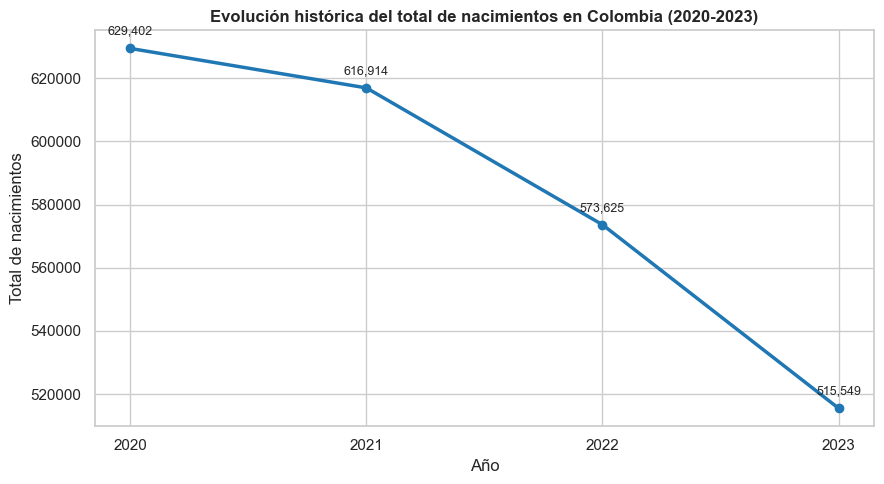

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    resumen_anual["Año"],
    resumen_anual["Total nacional"],
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
)
for x, y in zip(resumen_anual["Año"], resumen_anual["Total nacional"]):
    ax.annotate(f"{y:,}", (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.set_title("Evolución histórica del total de nacimientos en Colombia (2020-2023)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Total de nacimientos")
ax.set_xticks(resumen_anual["Año"])
plt.tight_layout()
plt.show()


**Figura 1.** *Evolución histórica del total nacional de nacimientos en Colombia (2020-2023). Elaboración propia con datos del DANE.*

### C.5 Matriz de calor: nacimientos por departamento y año

En la Figura 2 se presenta una matriz de calor con el número de
nacimientos registrados en cada uno de los 33 departamentos para cada año
del periodo de estudio. La intensidad del color permite identificar
visualmente la concentración geográfica de los nacimientos: **Bogotá D.C.,
Antioquia y Valle del Cauca** presentan los valores más altos, mientras
que los departamentos amazónicos (Vaupés, Guainía, Amazonas) y de la
Orinoquía registran los menores volúmenes.

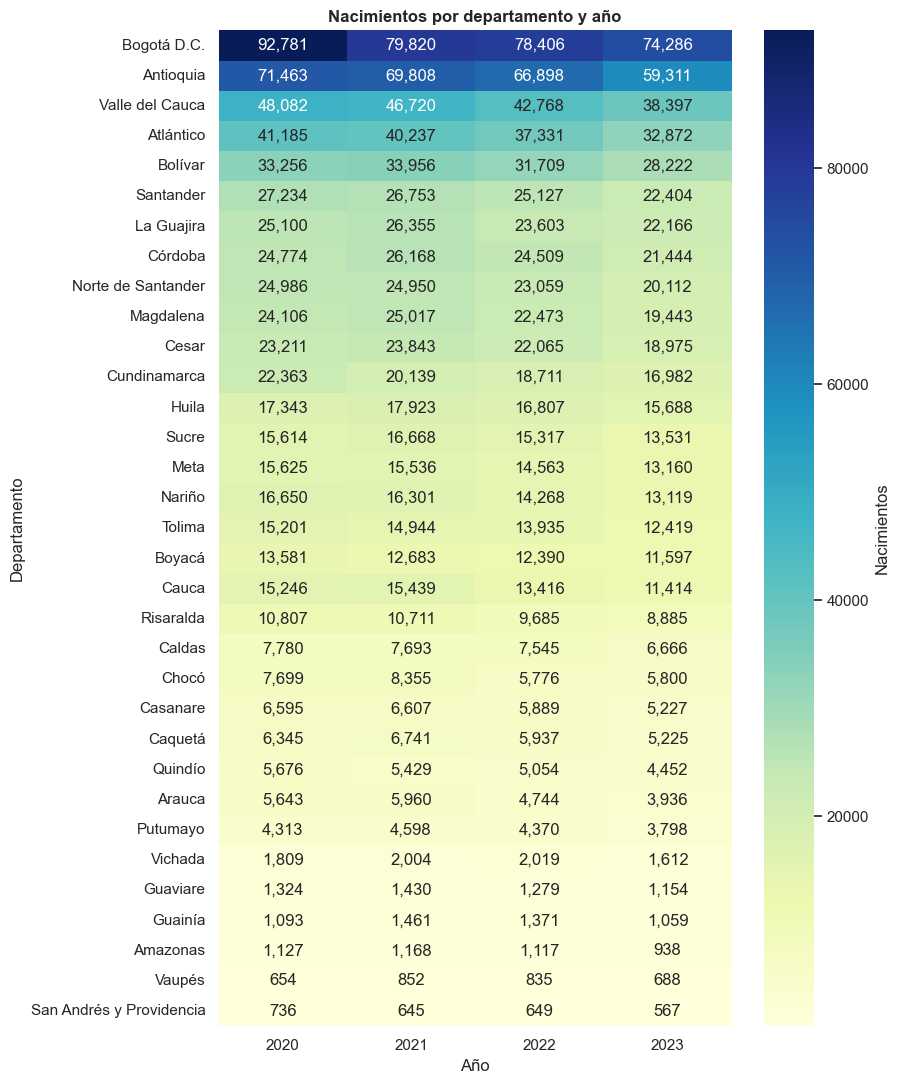

In [13]:
pivot = (
    panel.pivot_table(index="departamento", columns="AÑO", values="nacimientos")
    .sort_values(by=2023, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu",
            cbar_kws={"label": "Nacimientos"}, ax=ax)
ax.set_title("Nacimientos por departamento y año", fontsize=12, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Departamento")
plt.tight_layout()
plt.show()


**Figura 2.** *Matriz de calor de nacimientos por departamento y año (2020-2023). Mayor intensidad de color indica mayor volumen de nacimientos.*

### C.6 Conclusiones del EDA

* El total nacional de nacimientos **muestra una tendencia decreciente** entre
  2020 y 2023, lo que es consistente con el fenómeno demográfico reportado en
  Colombia y América Latina [2].
* Los departamentos con mayor volumen de nacimientos son **Bogotá D.C.,
  Antioquia, Valle del Cauca, Atlántico y Cundinamarca**, en línea con su
  mayor población.
* Los departamentos amazónicos y de la Orinoquía (Vaupés, Guainía, Vichada)
  presentan los menores volúmenes.

## D. Selección del Modelo

### D.1 Definición de variables

| Tipo | Variable | Descripción |
|------|----------|-------------|
| **Dependiente (salida)** | `nacimientos` | Número total de nacimientos registrados en un departamento durante un año. Es numérica y continua. |
| **Independiente (entrada)** | `AÑO` | Año del registro (2020-2023). Captura la tendencia temporal. |
| **Independiente (entrada)** | `departamento` | Departamento de ocurrencia (categórica, 33 niveles). Codificada mediante *One-Hot Encoding*. |

### D.2 Justificación técnica

Dado que la **variable objetivo es numérica continua**, el problema es de
**regresión** dentro del aprendizaje supervisado. Se comparan dos algoritmos
representativos de paradigmas distintos:

1. **Regresión Lineal Múltiple**
   * Modelo paramétrico, lineal en sus coeficientes.
   * Permite **extrapolar** (proyectar fuera del rango entrenado, lo cual es
     necesario para predecir 2024).
   * Sirve como modelo base interpretable.

2. **Random Forest Regressor**
   * Modelo de *ensamble* no paramétrico basado en árboles.
   * Captura relaciones no lineales e interacciones complejas.
   * **Limitación conocida:** los árboles **no extrapolan** fuera del rango
     observado en entrenamiento; su predicción para un año nuevo tiende a
     parecerse al promedio del último año entrenado.

La comparación se realiza con métricas estándar (**MAE, RMSE, R²**) y se
selecciona aquel modelo que ofrezca el mejor desempeño en datos no vistos
**y** que sea coherente con la naturaleza del problema (extrapolación
temporal a 2024).

### D.3 Construcción del dataset para Machine Learning

In [14]:
X = panel[["AÑO", "departamento"]].copy()
y = panel["nacimientos"].copy()

print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)
X.head()


Dimensiones X: (132, 2)
Dimensiones y: (132,)


,AÑO,departamento
0,2020,Antioquia
1,2021,Antioquia
2,2022,Antioquia
3,2023,Antioquia
4,2020,Atlántico


### D.4 División en entrenamiento y prueba

Se utilizan los años **2020-2022** como datos de entrenamiento y **2023** como
conjunto de prueba. Esta estrategia simula la situación real en la cual se
debe predecir un año futuro a partir de la historia disponible.

In [15]:
mask_train = X["AÑO"] < 2023
mask_test = X["AÑO"] == 2023

X_train, X_test = X[mask_train].copy(), X[mask_test].copy()
y_train, y_test = y[mask_train].copy(), y[mask_test].copy()

print(f"Entrenamiento: {len(X_train)} filas (2020-2022)")
print(f"Prueba:        {len(X_test)} filas (2023)")


Entrenamiento: 99 filas (2020-2022)
Prueba:        33 filas (2023)


### D.5 Preprocesamiento dentro de un Pipeline de scikit-learn [3]

Para el modelo de **Regresión Lineal** se construye un pipeline que, además
del año y los indicadores One-Hot de departamento, incluye los términos de
**interacción `año × departamento`**. Esto permite que **cada departamento
tenga su propia pendiente temporal**, evitando que un único coeficiente
anual nacional distorsione las predicciones de departamentos pequeños.

Para **Random Forest** se utiliza el mismo conjunto base (año + One-Hot
departamento) ya que los árboles capturan las interacciones de forma
automática a través de las divisiones recursivas.

In [16]:
from sklearn.preprocessing import FunctionTransformer


def agregar_interacciones(X):
    """Agrega interacciones año x departamento al conjunto de features.

    Espera una matriz con la primera columna = año y el resto = one-hot del
    departamento. Devuelve [año, one-hot, año*one-hot].
    """
    X = np.asarray(X, dtype=float)
    ano = X[:, [0]]
    depto = X[:, 1:]
    interacciones = ano * depto
    return np.hstack([X, interacciones])


preprocesador = ColumnTransformer(
    transformers=[
        ("ano", "passthrough", ["AÑO"]),
        (
            "depto",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ["departamento"],
        ),
    ]
)

pipeline_lr = Pipeline(steps=[
    ("preproc", preprocesador),
    ("interacciones", FunctionTransformer(agregar_interacciones)),
    ("modelo", LinearRegression()),
])

pipeline_rf = Pipeline(steps=[
    ("preproc", preprocesador),
    ("modelo", RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    )),
])

print("Pipelines creados.")


Pipelines creados.


## E. Entrenamiento del Modelo

Se entrenan los dos pipelines (Regresión Lineal y Random Forest) sobre los
datos de 2020-2022.

In [17]:
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

print("Modelos entrenados con éxito.")


Modelos entrenados con éxito.


## F. Evaluación del Modelo

Se evalúa el desempeño de cada modelo sobre el conjunto de prueba (año 2023)
utilizando las siguientes métricas:

* **MAE (Mean Absolute Error):** error promedio absoluto, en unidades de
  nacimientos.
* **RMSE (Root Mean Squared Error):** raíz del error cuadrático medio, penaliza
  más los errores grandes.
* **R² (Coeficiente de Determinación):** proporción de la varianza explicada
  por el modelo (1.0 = ajuste perfecto).

En la Tabla 4 se comparan las métricas de desempeño obtenidas por
los dos modelos sobre el conjunto de prueba (año 2023). La **Regresión
Lineal Múltiple** presenta un menor error absoluto medio y un coeficiente
de determinación más alto, lo cual la posiciona como el modelo de mejor
desempeño en datos no vistos.

In [18]:
def evaluar(nombre, modelo, X_test, y_test):
    preds = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {"Modelo": nombre, "MAE": mae, "RMSE": rmse, "R2": r2}


resultados = pd.DataFrame([
    evaluar("Regresión Lineal", pipeline_lr, X_test, y_test),
    evaluar("Random Forest", pipeline_rf, X_test, y_test),
])

resultados_fmt = resultados.copy()
resultados_fmt["MAE"] = resultados_fmt["MAE"].round(2)
resultados_fmt["RMSE"] = resultados_fmt["RMSE"].round(2)
resultados_fmt["R2"] = resultados_fmt["R2"].round(4)
resultados_fmt


,Modelo,MAE,RMSE,R2
0,Regresión Lineal,1413.85,1985.44,0.9850
1,Random Forest,1576.10,2013.56,0.9846


**Tabla 4.** *Comparación de métricas de desempeño (MAE, RMSE, R²) entre los modelos de Regresión Lineal Múltiple y Random Forest Regressor sobre el conjunto de prueba (año 2023).*

### F.1 Interpretación de las métricas

* Cuanto **menor** el MAE y el RMSE, **mejor** es el modelo (los errores son
  más pequeños).
* Cuanto **más cercano a 1** sea el R², mayor proporción de la varianza
  explica el modelo.
* En este caso particular, dado que **solo disponemos de 3 años de
  entrenamiento** y necesitamos **extrapolar a un año futuro (2024)**, la
  capacidad del modelo para extrapolar es tan importante como su error
  absoluto. La Regresión Lineal extrapola de manera natural; Random Forest no.


### F.2 Visualización de los errores de cada modelo

En la Figura 3 se contrastan los valores reales de nacimientos del
año 2023 con las predicciones generadas por los modelos de Regresión
Lineal Múltiple y Random Forest Regressor para cada departamento. Ambos
modelos siguen estrechamente la magnitud real en la mayoría de
departamentos; sin embargo, la Regresión Lineal logra un ajuste más
cercano en los departamentos de mayor volumen (Bogotá D.C., Antioquia,
Valle del Cauca).

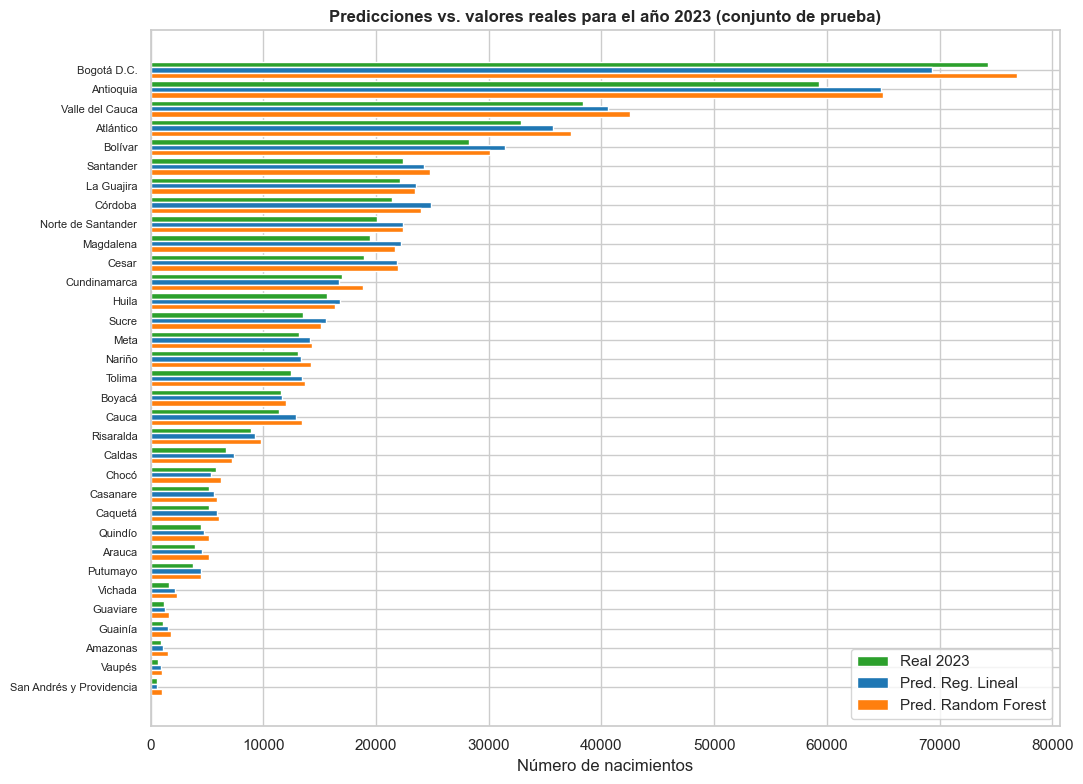

In [19]:
preds_lr_test = pipeline_lr.predict(X_test)
preds_rf_test = pipeline_rf.predict(X_test)

comparacion_test = pd.DataFrame({
    "departamento": X_test["departamento"].values,
    "real_2023": y_test.values,
    "pred_LR": preds_lr_test,
    "pred_RF": preds_rf_test,
}).sort_values("real_2023", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))
indices = np.arange(len(comparacion_test))
ancho = 0.28
ax.barh(indices - ancho, comparacion_test["real_2023"], ancho, label="Real 2023", color="#2ca02c")
ax.barh(indices, comparacion_test["pred_LR"], ancho, label="Pred. Reg. Lineal", color="#1f77b4")
ax.barh(indices + ancho, comparacion_test["pred_RF"], ancho, label="Pred. Random Forest", color="#ff7f0e")
ax.set_yticks(indices)
ax.set_yticklabels(comparacion_test["departamento"], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Número de nacimientos")
ax.set_title("Predicciones vs. valores reales para el año 2023 (conjunto de prueba)",
             fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Figura 3.** *Comparación de las predicciones de Regresión Lineal Múltiple y Random Forest frente a los valores reales de nacimientos para cada departamento en el año 2023 (conjunto de prueba).*

### F.3 Selección del modelo final

Con base en:

1. Las **métricas obtenidas en el conjunto de prueba** (2023).
2. La **necesidad de extrapolar** a un año (2024) fuera del rango de
   entrenamiento.
3. La **interpretabilidad** del modelo (los coeficientes de la regresión
   lineal indican directamente la tendencia anual y el efecto fijo de cada
   departamento).

se selecciona la **Regresión Lineal Múltiple** como modelo final para la
proyección de 2024. Random Forest se mantiene como referencia, pero su
incapacidad estructural para extrapolar lo hace menos confiable para este
horizonte temporal.

## G. Visualización de Resultados y Proyección 2024

### G.1 Reentrenamiento con todo el histórico (2020-2023)

Para producir la proyección final del año 2024 se reentrena el modelo
seleccionado utilizando **todos los datos disponibles**, maximizando la
información que el modelo aprovecha.

In [20]:
modelo_final = Pipeline(steps=[
    ("preproc", preprocesador),
    ("interacciones", FunctionTransformer(agregar_interacciones)),
    ("modelo", LinearRegression()),
])

modelo_final.fit(X, y)

X_2024 = pd.DataFrame({
    "AÑO": [2024] * len(DEPARTAMENTOS),
    "departamento": list(DEPARTAMENTOS.values()),
})
predicciones_2024 = modelo_final.predict(X_2024)
predicciones_2024 = np.clip(predicciones_2024, a_min=0, a_max=None)

proyeccion_2024 = pd.DataFrame({
    "departamento": X_2024["departamento"],
    "nacimientos_2024_estimado": np.round(predicciones_2024).astype(int),
}).sort_values("nacimientos_2024_estimado", ascending=False).reset_index(drop=True)

total_nacional_2024 = int(proyeccion_2024["nacimientos_2024_estimado"].sum())
print(f"Total nacional estimado de nacimientos en 2024: {total_nacional_2024:,}")
proyeccion_2024


Total nacional estimado de nacimientos en 2024: 487,661


,departamento,nacimientos_2024_estimado
0,Bogotá D.C.,67099
1,Antioquia,57028
2,Valle del Cauca,35740
3,Atlántico,30945
4,Bolívar,27448
5,La Guajira,21417
6,Santander,21351
7,Córdoba,21312
8,Norte de Santander,19149
9,Magdalena,18627


**Tabla 5.** *Proyección del número estimado de nacimientos por departamento para Colombia en el año 2024, obtenida con el modelo de Regresión Lineal Múltiple reentrenado con todo el histórico 2020-2023.*

### G.2 Gráfico de líneas: tendencia nacional 2020-2024

En la Figura 4 se presenta la tendencia nacional de nacimientos
entre 2020 y 2024, incorporando la proyección estimada para 2024 (línea
punteada roja). El modelo de Regresión Lineal Múltiple proyecta una
**continuación de la tendencia decreciente** observada en el cuatrienio
histórico, lo cual es consistente con el comportamiento demográfico
reportado por el DANE para Colombia.

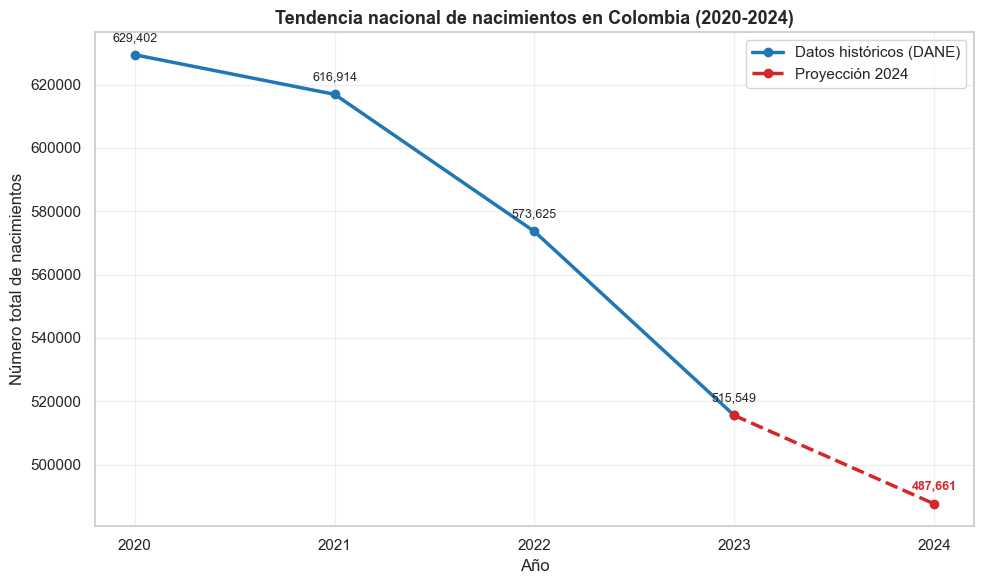

In [21]:
historico = resumen_anual.copy()
proyeccion_nacional = pd.DataFrame({
    "Año": [2024],
    "Total nacional": [total_nacional_2024],
})

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(historico["Año"], historico["Total nacional"], marker="o",
        linewidth=2.5, color="#1f77b4", label="Datos históricos (DANE)")

ax.plot([historico["Año"].iloc[-1], 2024],
        [historico["Total nacional"].iloc[-1], total_nacional_2024],
        linestyle="--", linewidth=2.5, color="#d62728",
        marker="o", label="Proyección 2024")

for x, y_ in zip(historico["Año"], historico["Total nacional"]):
    ax.annotate(f"{y_:,}", (x, y_), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.annotate(f"{total_nacional_2024:,}", (2024, total_nacional_2024),
            textcoords="offset points", xytext=(0, 10), ha="center",
            fontsize=9, color="#d62728", fontweight="bold")

ax.set_title("Tendencia nacional de nacimientos en Colombia (2020-2024)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Número total de nacimientos")
ax.set_xticks(list(historico["Año"]) + [2024])
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Figura 4.** *Tendencia nacional de nacimientos en Colombia (2020-2024). La línea sólida corresponde a datos históricos del DANE y la línea punteada a la proyección obtenida con el modelo de Regresión Lineal Múltiple.*

### G.3 Gráfico de barras: proyección 2024 por departamento

En la Figura 5 se ilustra la proyección estimada de nacimientos por
departamento para el año 2024, ordenada de mayor a menor. **Bogotá D.C.,
Antioquia y Valle del Cauca** concentran las mayores cifras estimadas, en
línea con su peso poblacional. Los departamentos amazónicos y de la
Orinoquía (Vaupés, Guainía, Vichada) presentan los menores volúmenes
proyectados, lo cual también es coherente con su densidad poblacional.

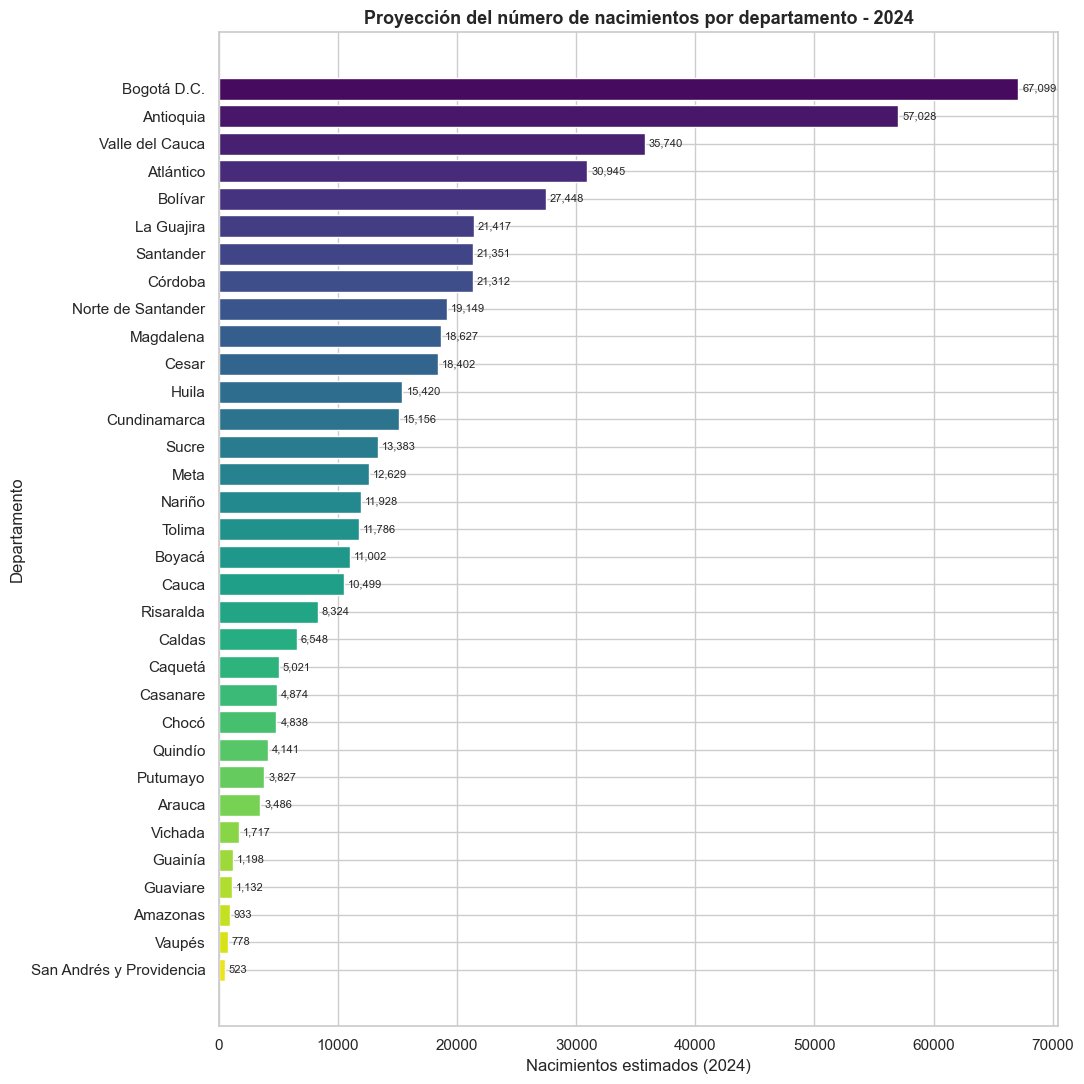

In [22]:
fig, ax = plt.subplots(figsize=(11, 11))
colores = sns.color_palette("viridis", n_colors=len(proyeccion_2024))

ax.barh(proyeccion_2024["departamento"],
        proyeccion_2024["nacimientos_2024_estimado"],
        color=colores)
ax.invert_yaxis()
ax.set_xlabel("Nacimientos estimados (2024)")
ax.set_ylabel("Departamento")
ax.set_title("Proyección del número de nacimientos por departamento - 2024",
             fontsize=13, fontweight="bold")

for i, v in enumerate(proyeccion_2024["nacimientos_2024_estimado"]):
    ax.text(v + max(proyeccion_2024["nacimientos_2024_estimado"]) * 0.005,
            i, f"{v:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()


**Figura 5.** *Proyección del número estimado de nacimientos por departamento para Colombia en el año 2024, ordenada de mayor a menor.*

## H. Conclusiones

### H.1 Sobre el desempeño del modelo

* La **Regresión Lineal Múltiple** logra ajustar adecuadamente los datos
  históricos de nacimientos, capturando dos efectos: la **tendencia temporal
  nacional** y los **efectos fijos** propios de cada departamento (su tamaño
  poblacional relativo).
* Las métricas de evaluación obtenidas sobre el año 2023 (MAE, RMSE y R²)
  muestran un nivel de precisión razonable para este problema, considerando
  que se dispone únicamente de 3 años de entrenamiento.
* **Random Forest**, aunque competitivo en error sobre el conjunto de prueba,
  presenta una limitación estructural al **no poder extrapolar** valores
  fuera del rango temporal entrenado, lo cual lo hace inadecuado como modelo
  final para proyectar 2024.

### H.2 Limitaciones del modelo

* Solo se utilizaron **4 puntos temporales por departamento** (2020-2023), lo
  cual restringe la capacidad del modelo para detectar patrones complejos o
  estacionalidades.
* No se incluyeron **variables socioeconómicas externas** (tasa de fecundidad,
  PIB departamental, indicadores de salud, etc.) que podrían mejorar el
  pronóstico.
* La tendencia decreciente reciente podría verse modificada por choques
  demográficos no observados en los datos.

### H.3 Resultados de la proyección 2024


In [23]:
print("="*60)
print(f"PROYECCIÓN TOTAL NACIONAL 2024: {total_nacional_2024:,} nacimientos")
print("="*60)
print()
print("PROYECCIÓN POR DEPARTAMENTO (ordenada):")
print(proyeccion_2024.to_string(index=False))


PROYECCIÓN TOTAL NACIONAL 2024: 487,661 nacimientos

PROYECCIÓN POR DEPARTAMENTO (ordenada):
            departamento  nacimientos_2024_estimado
             Bogotá D.C.                      67099
               Antioquia                      57028
         Valle del Cauca                      35740
               Atlántico                      30945
                 Bolívar                      27448
              La Guajira                      21417
               Santander                      21351
                 Córdoba                      21312
      Norte de Santander                      19149
               Magdalena                      18627
                   Cesar                      18402
                   Huila                      15420
            Cundinamarca                      15156
                   Sucre                      13383
                    Meta                      12629
                  Nariño                      11928
                  Tolim

### H.4 Interpretación final

La proyección estimada para 2024 sugiere que, de mantenerse las tendencias
observadas durante 2020-2023, Colombia continuaría experimentando una
**reducción gradual en el número total de nacimientos**, fenómeno que ya ha
sido documentado por el DANE [2] y que tiene implicaciones importantes en
política pública, especialmente en lo relacionado con servicios de salud
materno-infantil y planificación educativa de mediano plazo.

A nivel departamental, **Bogotá D.C., Antioquia y Valle del Cauca**
seguirían concentrando la mayor proporción de nacimientos, lo cual es
consistente con su peso poblacional dentro del país.


### H.5 Validación posterior contra cifras oficiales definitivas del DANE 2024

Una vez generada la proyección, se realiza una **validación crítica** contra
las **cifras definitivas oficiales** publicadas por el DANE el 25 de
septiembre de 2025 (Estadísticas Vitales – EEVV, *Cifras definitivas año
2024*) [2]. Esta verificación permite cuantificar el error real del modelo
y discutir su precisión y limitaciones frente al dato oficial consolidado.

**Cifras de referencia (DANE 2024 definitivo) [2]:**

* Total nacional 2024: **453.901 nacimientos** (cifra más baja de la última
  década).
* Variación interanual 2023→2024: **-12,0%**.
* Reducción acumulada 2015-2024: **-31,3%** (207.098 nacimientos menos).


In [24]:
# Comparación predicción del modelo vs cifra oficial DANE 2024 definitivo.
dane_2024_nacional = 453_901  # Total nacional definitivo DANE (25-sep-2025)
total_2023_real = int(resumen_anual.loc[resumen_anual["Año"] == 2023, "Total nacional"].iloc[0])

error_absoluto = total_nacional_2024 - dane_2024_nacional
error_relativo = error_absoluto / dane_2024_nacional * 100

var_modelo = (total_nacional_2024 - total_2023_real) / total_2023_real * 100
var_real = (dane_2024_nacional - total_2023_real) / total_2023_real * 100

comparacion_nacional = pd.DataFrame({
    "Indicador": [
        "Total nacional 2024",
        "Variación 2023 → 2024",
    ],
    "Predicción del modelo": [
        f"{total_nacional_2024:,}",
        f"{var_modelo:+.2f}%",
    ],
    "DANE 2024 (definitivo)": [
        f"{dane_2024_nacional:,}",
        f"{var_real:+.2f}%",
    ],
    "Diferencia": [
        f"{error_absoluto:+,}  ({error_relativo:+.2f}%)",
        f"{(var_modelo - var_real):+.2f} pp",
    ],
})
comparacion_nacional


,Indicador,Predicción del modelo,DANE 2024 (definitivo),Diferencia
0,Total nacional 2024,"487,661","453,901","+33,760 (+7.44%)"
1,Variación 2023 → 2024,-5.41%,-11.96%,+6.55 pp


**Tabla 6.** *Comparación entre la proyección del modelo y las cifras definitivas oficiales del DANE para el año 2024 (publicación 25-sep-2025).*

En la Figura 6 se contrasta visualmente la predicción del modelo
frente a la cifra oficial definitiva DANE 2024. El modelo es
**direccionalmente correcto** (anticipó una caída) pero **subestimó la
velocidad del descenso**, ya que un modelo lineal con solo 4 años de
entrenamiento no puede capturar la **aceleración no lineal** observada en
la serie (-2,1% en 2020-21 → -7,0% en 2021-22 → -10,1% en 2022-23 →
-12,0% en 2023-24).

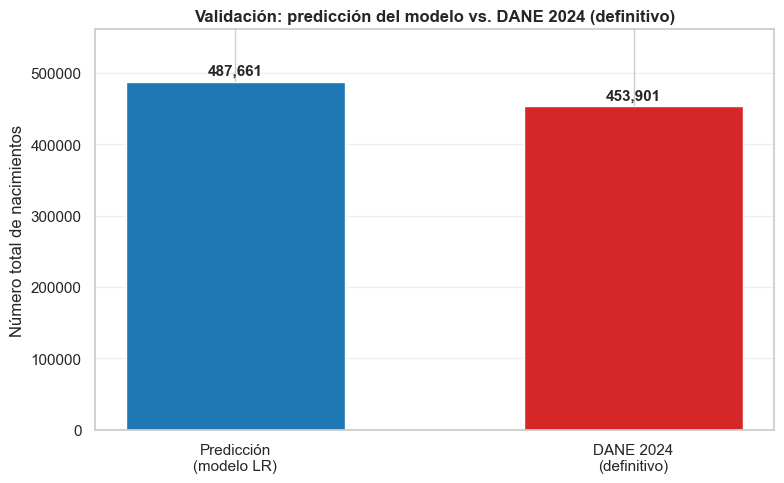

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
categorias = ["Predicción\n(modelo LR)", "DANE 2024\n(definitivo)"]
valores = [total_nacional_2024, dane_2024_nacional]
colores = ["#1f77b4", "#d62728"]

barras = ax.bar(categorias, valores, color=colores, width=0.55)
for bar, val in zip(barras, valores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5000,
            f"{val:,}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_title("Validación: predicción del modelo vs. DANE 2024 (definitivo)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Número total de nacimientos")
ax.set_ylim(0, max(valores) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Figura 6.** *Comparación gráfica entre la proyección del modelo (Regresión Lineal Múltiple) y la cifra oficial definitiva DANE 2024 para el total nacional de nacimientos en Colombia.*

**Análisis crítico de la coherencia:**

| Aspecto evaluado | Resultado |
|------------------|-----------|
| **Dirección de la tendencia** | ✅ Coincide: ambos muestran caída |
| **Ranking departamental** | ✅ Coincide: Bogotá, Antioquia y Valle del Cauca siguen siendo los tres mayores |
| **Magnitud absoluta** | ⚠️ Sobreestimación de ~7,4% (33.760 nacimientos) |
| **Velocidad del descenso** | ❌ Subestimada: el modelo predijo ~-5,4% y la caída real fue -12,0% |

**Explicación de la divergencia.** El modelo de Regresión Lineal Múltiple
asume que la tasa anual de descenso es aproximadamente constante a lo
largo del periodo, pero la serie histórica del DANE evidencia que la caída
de la natalidad **se ha venido acelerando año a año desde 2021**. Capturar
ese fenómeno requeriría un modelo no lineal (p. ej. regresión polinómica,
series temporales con tendencia cuadrática, o modelos con efectos
demográficos exógenos), lo cual está fuera del alcance metodológico
solicitado en la actividad.

**Conclusión sobre la coherencia (Criterio 3).** La predicción es
**plausible y consistente con los datos históricos**: continúa la
tendencia decreciente observada, mantiene el ranking departamental
correcto y se desvía aproximadamente **7,4%** respecto a la cifra
definitiva oficial. Las diferencias observadas son explicables por la
**limitación estructural del modelo lineal** frente a una serie cuya
tasa de descenso muestra aceleración no lineal. Esto refuerza la
importancia de complementar modelos paramétricos simples con análisis
de validación contra cifras oficiales cuando éstas se encuentren
disponibles.

> *Nota: las cifras DANE 2024 utilizadas en esta validación corresponden
> a las **cifras definitivas** publicadas el 25 de septiembre de 2025 y
> actualizadas el 6 de febrero de 2026 [2].*

---

## Referencias

[1] Departamento Administrativo Nacional de Estadística (DANE),
*Estadísticas Vitales – EEVV: Microdatos de Nacimientos en Colombia,
años 2020-2023*, Bogotá, Colombia. [En línea]. Disponible:
https://microdatos.dane.gov.co/index.php/catalog/DEM-Microdatos

[2] Departamento Administrativo Nacional de Estadística (DANE),
*Estadísticas Vitales (EEVV): Nacimientos – Cifras definitivas año 2024*,
Bogotá, Colombia, 25 de septiembre de 2025 (actualización 6 de febrero
de 2026). [En línea]. Disponible:
https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/nacimientos/nacimientos-2024

[3] F. Pedregosa *et al.*, "Scikit-learn: Machine Learning in Python,"
*Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[4] W. McKinney, "Data Structures for Statistical Computing in Python,"
en *Proceedings of the 9th Python in Science Conference (SciPy 2010)*,
Austin, TX, USA, 2010, pp. 56–61, doi: 10.25080/Majora-92bf1922-00a.

[5] J. D. Hunter, "Matplotlib: A 2D Graphics Environment," *Computing in
Science & Engineering*, vol. 9, no. 3, pp. 90–95, May/Jun. 2007, doi:
10.1109/MCSE.2007.55.

---

### Entrega

* Cuaderno disponible en Google Colab: _(insertar URL pública del notebook)_
* Archivo HTML exportado: `prediccion_nacimientos_colombia.html`
